In [1]:
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 80.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]
fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
/home/jovyan/work/20260413_token/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-04-13 12:54:19--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.136, 13.200.41.135, 13.200.41.134, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.136|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-13 12:54:19 ERROR 404: Not Found

In [2]:
from konlpy.tag import Mecab

mecab = Mecab()
print(mecab.morphs('자연어처리가너무재밌어서밥먹는것도가끔까먹어요'))

['자연어', '처리', '가', '너무', '재밌', '어서', '밥', '먹', '는', '것', '도', '가끔', '까먹', '어요']


In [3]:
import os

import matplotlib.pyplot as plt
import torch
import numpy as np

%matplotlib inline

## 데이터 다운로드 및 분석

- 한국어의 형태소 분석과 품사 태깅, 기계 번역 연구를 위해 공개된 데이터이다. 이번에 사용할 데이터는 한국어-영어 병렬을 이루는 말뭉치 중 한국어 부분으로, 전체 병렬 말뭉치는 후에 번역기를 만들며 사용할 예정

In [4]:
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!tar -xzvf korean-english-park.train.tar.gz

--2026-04-13 12:57:05--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-04-13 12:57:06--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘korean-english-park.train.tar.gz.1’

korean

In [5]:
import os
path_to_file = "korean-english-park.train.ko"

with open(path_to_file, "r") as f:
    raw = f.read().splitlines()

print("Data Size:", len(raw))

print("Example:")
for sen in raw[0:100][::20]: print(">>", sen)

Data Size: 94123
Example:
>> 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
>> 북한의 핵무기 계획을 포기하도록 하려는 압력이 거세지고 있는 가운데, 일본과 북한의 외교관들이 외교 관계를 정상화하려는 회담을 재개했다.
>> "경호 로보트가 침입자나 화재를 탐지하기 위해서 개인적으로, 그리고 전문적으로 사용되고 있습니다."
>> 수자원부 당국은 논란이 되고 있고, 막대한 비용이 드는 이 사업에 대해 내년에 건설을 시작할 계획이다.
>> 또한 근력 운동은 활발하게 걷는 것이나 최소한 20분 동안 뛰는 것과 같은 유산소 활동에서 얻는 운동 효과를 심장과 폐에 주지 않기 때문에, 연구학자들은 근력 운동이 심장에 큰 영향을 미치는지 여부에 대해 논쟁을 해왔다.


문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 60


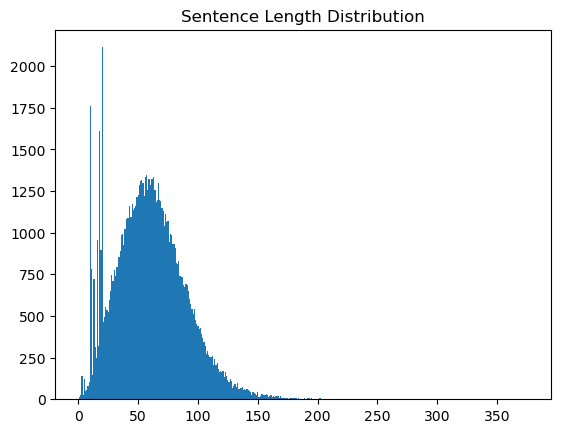

In [6]:
min_len = 999
max_len = 0
sum_len = 0

for sen in raw:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(raw))

sentence_length = np.zeros((max_len), dtype=int)

for sen in raw:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

## 데이터 타혐점  
1. 길이 1 짜리 문장은 도대체 어떻게 생겨먹었지?
2. 앞에 치솟는 임의의 구간은 뭐지? 유의미한 데이터가 담겨있는 부분인가?
3. 어디서부터 어디까지 잘라서 쓰지?

In [7]:
# 길이가 1인 문장
def check_sentence_with_length(raw, length):
    count = 0

    for sen in raw:
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100: return

check_sentence_with_length(raw, 1)

’


- 단어가 아닌 , 가 1 문장으로 포함되어있다

In [8]:
for idx, _sum in enumerate(sentence_length):
    # 문장의 수가 1500을 초과하는 문장 길이를 추출합니다.
    if _sum > 1500:
        print("Outlier Index:", idx+1)

Outlier Index: 11
Outlier Index: 19
Outlier Index: 21


In [9]:
# 길이가 11인 문장들
check_sentence_with_length(raw, 11)

라고 조던이 말했다.
- 모르고 있습니다.
- 네, 보이는군요.
디즈니사만이 아니다.
큰 파티는 아니지요.
의자는 비어 있었다.
이 일은 계속됩니다.
나는 크게 실망했다.
그 이유는 간단하다.
이력서와 자기 소개서
시대가 변하고 있다.
는 돌발질문을 했다.
9. 몇 분간의 명상
하와이, 빅 아일랜드
키스를 잘 하는 방법
키스를 잘 하는 방법
스피어스가 뚱뚱한가?
산 위를 나는 느낌.
세 시간쯤 걸었을까?
(아직 읽고있습니까?
처음에는 장난이었다.
우리는 운이 좋았다.
아기가 숨을 멈출 때
건물 전체 무너져내려
그녀의 아름다운 눈.
대답은 다음과 같다.
"사과할 것이 없다.
폭탄테러가 공포 유발
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
그는 "잘 모르겠다.
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1200원대로…
더 내려야 하는 이유
케냐 야생동물 고아원
경유 1

### set을 이용해서, 중복을 허용하지 않아 변환 과정에서 자동으로 중복된 요소를 제거

Data Size: 77591
문장의 최단 길이: 1
문장의 최장 길이: 377
문장의 평균 길이: 64


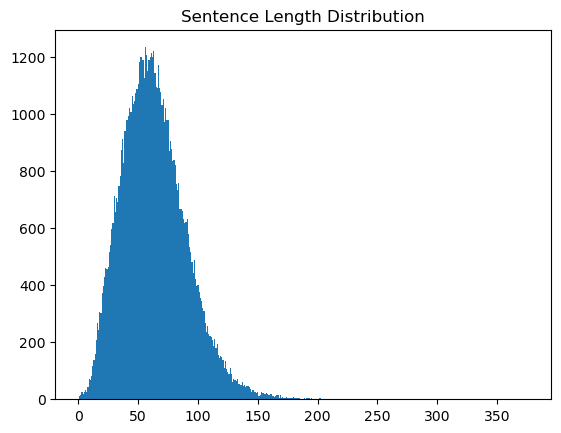

In [10]:
min_len = 999
max_len = 0
sum_len = 0

cleaned_corpus = list(set(raw))  # set를 사용해서 중복을 제거합니다.
print("Data Size:", len(cleaned_corpus))

for sen in cleaned_corpus:
    length = len(sen)
    if min_len > length: min_len = length
    if max_len < length: max_len = length
    sum_len += length

print("문장의 최단 길이:", min_len)
print("문장의 최장 길이:", max_len)
print("문장의 평균 길이:", sum_len // len(cleaned_corpus))

sentence_length = np.zeros((max_len), dtype=int)

for sen in cleaned_corpus:   # 중복이 제거된 코퍼스 기준
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

- 모든 데이터를 다 사용할 것이냐, 가 문제이다. 후에 미니 배치를 만들 것을 생각하면 모든 데이터를 다 사용하는 것은 연산 측면에서 비효율적이다. 미니 배치 특정상 각 데이터의 크기가 모두 동일해야하기 때문에 가장 긴 데이터를 기준으로 padding 처리를 해야한다.
- 길이별로 정렬하여 미니 배치를 구성해 padding을 최소화하는 방법도 있지만 이는 데이터를 섞는 데 편향성이 생길 수 있으므로 지양해야한다
- 너무 짧은 데이터는 오히려 노이즈(ex: ',') 로 작용할 수 있다. 따라서 길ㄹ이가 10 미만인 데이터도 제거

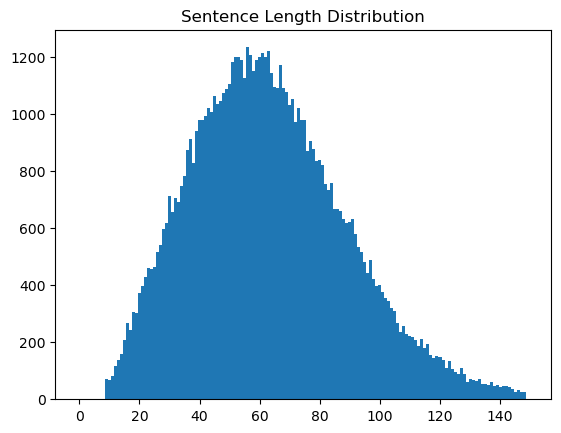

In [11]:
max_len = 150
min_len = 10

# 길이 조건에 맞는 문장만 선택합니다.
filtered_corpus = [s for s in cleaned_corpus if (len(s) < max_len) & (len(s) >= min_len)]

# 분포도를 다시 그려봅니다.
sentence_length = np.zeros((max_len), dtype=int)

for sen in filtered_corpus:
    sentence_length[len(sen)-1] += 1

plt.bar(range(max_len), sentence_length, width=1.0)
plt.title("Sentence Length Distribution")
plt.show()

## **공백 기반 토큰화**

In [12]:
import torch
from torch.nn.utils.rnn import pad_sequence

class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        # 각 문장을 토큰화하여 단어 사전을 생성 (인덱스는 1부터 시작)
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        # 역방향 사전 생성
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            # 존재하지 않는 단어는 0으로 처리
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            # tensor인 경우 리스트로 변환
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            # 패딩 토큰(0)은 제외하고 디코딩
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

In [13]:
def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    # padding 토큰은 0
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [14]:
# 정제된 데이터 filtered_corpus를 공백 기반으로 토큰화하여 저장하는 코드를 직접 작성해 보세요.
split_corpus = []

for kor in filtered_corpus:
    split_corpus.append(kor.split())

In [15]:
len(split_corpus)

76908

In [16]:
split_tensor, split_tokenizer = tokenize(split_corpus)

print("Split Vocab Size:", len(split_tokenizer.index_word))

Split Vocab Size: 238305


In [17]:
for idx, word in enumerate(split_tokenizer.word_index):
    print(idx, ":", word)

    if idx > 10: break

0 : 새해들어
1 : 두
2 : 번째
3 : 거래일을
4 : 맞은
5 : 월스트리트에서는
6 : 장이
7 : 열리면서
8 : 다우산업지수가
9 : 94포인트
10 : 하락했으며,
11 : 나스닥은


#### **공백 기반 토큰화의 문제점**
- 유사한 의미를 지니고 있음에도 전혀 다른 단어로 분류 -> 공백 기반 토큰화는 불필요하게 큰 단어 사전을 가지게 되며 이는 연산량 증가로 이어짐
- '밝 + 혔다' 라고 토큰화했다면,'밝+히다','밝+다' 같은 구절이 등장했을 대, 공통된 어절인 '밝'은 하나로 묶어 학습 중에 의미를 파악하기가 수월해졌을 것

## **형태소 기반 토큰화**

In [18]:
# 위에서 사용한 코드를 활용해 MeCab 단어 사전을 만들어보세요.
# Hint : mecab.morphs()를 사용해서 형태소분석을 합니다.
def mecab_split(sentence):
    return mecab.morphs(sentence)

mecab_corpus = []

for kor in filtered_corpus:
    mecab_corpus.append(mecab_split(kor))

In [19]:
mecab_tensor, mecab_tokenizer = tokenize(mecab_corpus)

print("MeCab Vocab Size:", len(mecab_tokenizer.index_word))

MeCab Vocab Size: 53642


- 공백 기반 단어 사전에 비해 단어 수가 현저히 줄어든 것을 확인할 수 있다. --> 연산량 감소 + 빠른 학습 가능 + 모델이 튜닝해야하는 매개변수(paramter) 수가 줄어들어 학습도 더 잘 된다 ==> 한국어 처리할 때는 공백 기반 토큰화를 절대 지양
- KorBERT는 SentencePice같은 subword 기반 토큰화보다 형태소 분석기가 좋은 성능을 내는 사례들이 종종 있다

## Dencoding 하는 과정  
- tokenizer.sequences_to_texts() 함수를 사용하여 Decoding
- tokenizer.index_word 를 사용하여 Decoding

In [20]:
# Case 1 : tokenizer.sequences_to_texts()

texts = mecab_tokenizer.sequences_to_texts([mecab_tensor[100]])
print(texts[0])

['BMW', '는', '올해', '매출', '이', '2007', '년', '보다', '더', '오를', '것', '으로', '전망', '했', '다', '.']


In [21]:
# Case 2 : tokenizer.index_word

sentence = ""

for w in mecab_tensor[100]:
    w = int(w)
    if w == 0: continue
    sentence += mecab_tokenizer.index_word[w] + " "

print(sentence)

BMW 는 올해 매출 이 2007 년 보다 더 오를 것 으로 전망 했 다 . 


In [22]:
import torch
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import konlpy

print(torch.__version__)
print(np.__version__)
print(matplotlib.__version__)
print(konlpy.__version__)

2.7.1+cu118
2.2.6
3.10.3
0.6.0


## **프로젝트 : SentencePiece 사용하기**

## setp1 : sentencePiece 설치하기

In [23]:
! pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 254.0 kB/s eta 0:00:00a 0:00:02


## step2 : sentencePiece 모델 학습

In [24]:
class Tokenizer:
    def __init__(self, filters=''):
        self.word_index = {}
        self.index_word = {}
        self.filters = filters

    def fit_on_texts(self, corpus):
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            for token in tokens:
                if token not in self.word_index:
                    self.word_index[token] = len(self.word_index) + 1
        self.index_word = {idx: word for word, idx in self.word_index.items()}

    def texts_to_sequences(self, corpus):
        sequences = []
        for sentence in corpus:
            tokens = sentence.split() if isinstance(sentence, str) else sentence
            seq = [self.word_index.get(token, 0) for token in tokens]
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

    def sequences_to_texts(self, sequences):
        texts = []
        for seq in sequences:
            if isinstance(seq, torch.Tensor):
                seq = seq.tolist()
            tokens = [self.index_word.get(idx, "") for idx in seq if idx != 0]
            texts.append(tokens)
        return texts

def tokenize(corpus):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(corpus)
    sequences = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequence(sequences, batch_first=True, padding_value=0)
    return tensor, tokenizer

In [25]:
import sentencepiece as spm
import os
temp_file = 'korean-english-park.train.ko.temp'

vocab_size = 8000

with open(temp_file, 'w') as f:
    for row in filtered_corpus:   # 이전에 나왔던 정제했던 corpus를 활용해서 진행해야 합니다.
        f.write(str(row) + '\n')

spm.SentencePieceTrainer.Train(
    '--input={} --model_prefix=korean_spm --vocab_size={}'.format(temp_file, vocab_size)    
)
#위 Train에서  --model_type = unigram이 디폴트 적용되어 있습니다. --model_type = bpe로 옵션을 주어 변경할 수 있습니다.

!ls -l korean_spm*

-rw-rw-r-- 1 jovyan users 379826 Apr 13 12:57 korean_spm.model
-rw-rw-r-- 1 jovyan users 146754 Apr 13 12:57 korean_spm.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=korean-english-park.train.ko.temp --model_prefix=korean_spm --vocab_size=8000
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: korean-english-park.train.ko.temp
  input_format: 
  model_prefix: korean_spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  b

### 모델 학습이 완료된 후 1. korea_spm.model 파일과 2. korea_spm.vocab  vocabulary 파일이 생성

In [26]:
s = spm.SentencePieceProcessor()
s.Load('korean_spm.model')

# SentencePiece를 활용한 sentence -> encoding
tokensIDs = s.EncodeAsIds('아버지가방에들어가신다.')
print(tokensIDs)

# SentencePiece를 활용한 sentence -> encoded pieces
print(s.SampleEncodeAsPieces('아버지가방에들어가신다.',-1, 0.1))

# SentencePiece를 활용한 encoding -> sentence 복원
print(s.DecodeIds(tokensIDs))

[1246, 11, 302, 7, 3541, 11, 287, 33, 4]
['▁', '아버지', '가', '방', '에', '들', '어', '가', '신', '다', '.']
아버지가방에들어가신다.


###  step3 : Tokenizer 함수 작성  
- sentencePiece를 활용하여 위 함수와 유사한 기능을 하는 sp_tokenize() 함수를 정의. sentencePiece가 동작하는 방식이 단순 토큰화와는 달라 동일하게 정의하기는 어렵다.아래 조건을 만족하는 함수를 정의해야한다
- 1. 매개 변수로 토큰화된 문장의 list를 전달하는 대신 온전한 문장의 list를 전달한다
  2. 생성된 vocab v파일을 읽어와 {<word> : <idx>} 형태를 가지는 word_index 사전과 {<idx> : <word>} 형태를 가지는 index_word 사전을 생성하고 함께 반환한다
  3. 리턴값인 tensor는 앞의 함수와 동일하게 토큰화한 후 Encoding 된 문장이다 .바로 학습에 사용할 수 있게 padding을 해야한다

In [120]:
def sp_tokenize(s, corpus):

    # 각 문장을 숫자 시퀀스로 저장할 리스트
    tensor = []

    # SentencePiece를 이용해서 문장을 숫자 ID로 변환
    for sen in corpus:
        tensor.append(s.EncodeAsIds(sen))

    # SentencePiece 가 만든 vocab 파일 읽기
    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    # 단어->숫자, 숫자->단어 맵핑
    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        # vocab 파일에서 토큰만 추출
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    # padding 수행
    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

### step4 : 네이버 영화리뷰 감정 분석 문제에SentencePiece 적용해보기

- 네이버 영화리뷰 감정 분석 코퍼스에 SentencePiece를 적용시킨 모델 학습하기
- 학습된 모델로 sp_tokenize() 메소드 구현하기
- 구현된 토크나이저를 적용하여 네이버 영화리뷰 감정 분석 모델을 재학습하기
- KoNLPy 형태소 분석기를 사용한 모델과 성능 비교하기
- SentencePiece 모델의 model_type, vocab_size 등을 변경해 가면서 성능 개선 여부 확인하기

In [139]:
# !wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
# !wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
# !mv ratings_*.txt ~/work/sentiment_classification/data

In [140]:
# !pip install konlpy
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
# %cd Mecab-ko-for-Google-Colab/
# !bash install_mecab-ko_on_colab_light_220429.sh

In [30]:
import os
print(os.getcwd())

/home/jovyan/work/20260413_token/Mecab-ko-for-Google-Colab/Mecab-ko-for-Google-Colab


In [31]:
import pandas as pd
import os

# 데이터를 읽어봅시다.
train_data = pd.read_table('/home/jovyan/work/20260413_token/ratings_train.txt')
test_data = pd.read_table('/home/jovyan/work/20260413_token/ratings_test.txt')

train_data.head()

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [32]:
from konlpy.tag import Mecab
import numpy as np
from collections import Counter

tokenizer = Mecab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def load_data(train_data, test_data, num_words=10000):
    train_data.drop_duplicates(subset=['document'], inplace=True)
    train_data = train_data.dropna(how = 'any')
    test_data.drop_duplicates(subset=['document'], inplace=True)
    test_data = test_data.dropna(how = 'any')

    X_train = []
    for sentence in train_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_train.append(temp_X)

    X_test = []
    for sentence in test_data['document']:
        temp_X = tokenizer.morphs(sentence) # 토큰화
        temp_X = [word for word in temp_X if not word in stopwords] # 불용어 제거
        X_test.append(temp_X)

    # vocab 만들기
    words = np.concatenate(X_train).tolist()
    counter = Counter(words)
    counter = counter.most_common(10000-4)
    vocab = ['', '', '', ''] + [key for key, _ in counter]
    word_to_index = {word:index for index, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index[word] if word in word_to_index else word_to_index[''] for word in wordlist]

    # encoding
    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, np.array(list(train_data['label'])), X_test, np.array(list(test_data['label'])), word_to_index

X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data)

In [33]:
index_to_word = {index:word for word, index in word_to_index.items()}
word_to_index["<PAD>"] = 0
word_to_index["<BOS>"] = 1
word_to_index["<UNK>"] = 2  # unknown
word_to_index["<UNUSED>"] = 3

In [34]:
x_train_padded = torch.nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in X_train], batch_first=True, padding_value=0)
x_test_padded  = torch.nn.utils.rnn.pad_sequence([torch.tensor(seq) for seq in X_test], batch_first=True, padding_value=0)

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

# 모델 정의
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_units=128):
        super(LSTMModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_units, batch_first=True)
        self.fc = nn.Linear(hidden_units, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)              # (batch, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(x)      # hidden: (1, batch, hidden_units)
        x = hidden[-1]                     # (batch, hidden_units)
        x = self.fc(x)
        x = self.sigmoid(x)
        return x

In [36]:
def train(model, EPOCH, loss_fn, optimizer, train_loader, val_loader):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model = model.to(device)

    for epoch in range(EPOCH):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            predicted = (probs.squeeze() > 0.5).float()

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)

        # 🔹 validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                # 🔥 validation도 GPU로
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), labels)

                val_loss += loss.item()

                probs = torch.sigmoid(outputs)
                predicted = (probs.squeeze() > 0.5).float()

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(val_correct / val_total)

        print(f"Epoch {epoch+1}/{EPOCH} - "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} - "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [80]:
def test(model, test_loader):
    model = model.to(device)
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = loss_fn(outputs.squeeze(), labels)
            test_loss += loss.item()

            probs = torch.sigmoid(outputs)
            predicted = (probs.squeeze() > 0.5).float()

            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = test_correct / test_total

    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.4f}")

    return avg_loss, accuracy

In [37]:
import random

random.seed(20260412)

loss_fn = torch.nn.BCELoss()
bcelogit_loss_fn = torch.nn.BCEWithLogitsLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

loss_fn = loss_fn.to(device)
bcelogit_loss_fn=bcelogit_loss_fn.to(device)
EPOCH = 20

Using device: cuda


In [134]:
def plot_training_history(train_losses, val_losses, train_accs, val_accs, title="Training Results"):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))
    plt.suptitle(title, fontsize=16)

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, color='blue', marker='o', label='Train Loss')
    plt.plot(epochs, val_losses, color='red', marker='o', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()
    plt.ylim([0,0.8])
    plt.xticks(np.arange(1, len(train_losses)+2, 4))
    plt.grid()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, color='blue', marker='o', label='Train Acc')
    plt.plot(epochs, val_accs, color='red', marker='o', label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.grid()
    plt.ylim([0,1])
    plt.xticks(np.arange(1, len(train_losses)+2, 4))

    plt.tight_layout()

    
    plt.show()

In [38]:
vocab_size = len(word_to_index)
word_vector_dim = 200

lstm_model= LSTMModel(vocab_size)
lstm_model.to(device)

LSTMModel(
  (embedding): Embedding(10001, 100)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

# **SentencePice Project**

In [97]:
# 문장 길이 리스트
lengths = [len(sentence) for sentence in train_data['document']]

# 기본 통계
print(f"최소 길이: {np.min(lengths)}")
print(f"최대 길이: {np.max(lengths)}")
print(f"평균 길이: {np.mean(lengths):.2f}")
print(f"중앙값: {np.median(lengths)}")

최소 길이: 1
최대 길이: 146
평균 길이: 35.98
중앙값: 27.0


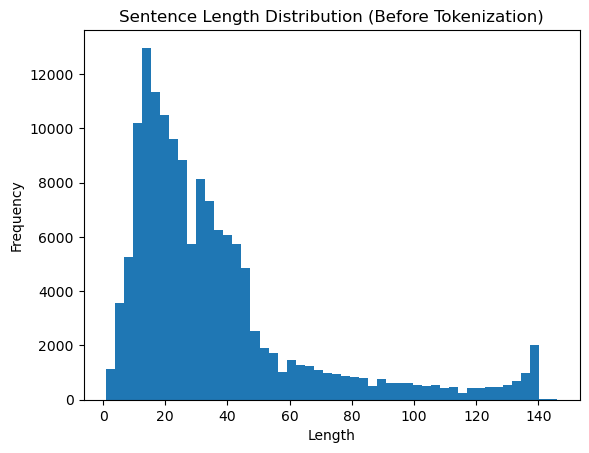

In [98]:
plt.hist(lengths, bins=50)
plt.title("Sentence Length Distribution (Before Tokenization)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

### 길이가 1인 데이터 확인

In [107]:
def check_sentence_with_length2(data, length):
    count = 0

    for sen in data['document']:  # 🔥 여기 중요
        if len(sen) == length:
            print(sen)
            count += 1
            if count > 100:
                return
check_sentence_with_length2(train_data, 1)

아
잼
1
4
굿
짱
휴
.
음
?
ㅎ
ㅋ
즐
♥
굳
네
ㅇ
k
ㅠ
쒯
♬
토
O
똥
z
헐
삼
꽝
!
풉
ㅅ
왜
ㄴ
쉣
봐
뿌
ㅜ
♡
ㅁ
0
ㅉ
d
흥
乃
찜
귯
린
시
ㅗ
a
c
흠
웅
ㅣ
오
9
쩜
애
헝
쨩
f
움
ㄳ
업
헉
군
b
;
g
올
걍
허
-
쀍
로
ㄹ
ㅂ
갑
즛
킥
함
진
ㅡ
잠
곧
ㅍ
h
·
캬
ㅆ
,
풋
ㄱ
파
ㄷ
웩
꺅
욜
ㅄ
2
핡


In [109]:
# 텍스트 파일 만들기
# NaN 제거
train_data = train_data.dropna(subset=['document'])
# 길이 1 제거
train_data = train_data[train_data['document'].str.len() > 1]

# test
test_data = test_data.dropna(subset=['document'])
test_data = test_data[test_data['document'].str.len() > 1]



with open('nsmc.txt', 'w', encoding='utf-8') as f:
    for sentence in train_data['document']:
        f.write(sentence + '\n')

# 학습
# SentencePiece 학습 
# 자주 나오는 문자열 찾기
# 단어를 어떻게 쪼갤지 결정
# vocab 생성
# 이러한 규칙을 자동으로 학습
spm.SentencePieceTrainer.Train(
    input='nsmc.txt',
    model_prefix='spm',
    vocab_size=8000
)



sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc.txt
  input_format: 
  model_prefix: spm
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_p

In [48]:
sp = spm.SentencePieceProcessor()
sp.load('spm.model')


True

In [49]:
'''
기존 방식(Mecab)

# 형태소 단위로 쪼갬 (예: "재밌다" → ["재밌", "다"])
temp_X = tokenizer.morphs(sentence)

# 불용어 제거  (의, 는, 이 같은 것 제거)
temp_X = [word for word in temp_X if not word in stopwords]
'''

### SentencePiece 방식

In [61]:
#temp_X = sp.encode(sentence, out_type=int)
# -> 문장을 subword 단위로 쪼개고 동시에 숫자로 변환까지 해줌
# 문장을 모델이 이해할 수 있는 숫자 형태로 변환

In [110]:
def load_data_sp(train_data, test_data):
    train_data = train_data.drop_duplicates(subset=['document']).dropna()
    test_data = test_data.drop_duplicates(subset=['document']).dropna()

    # sentencepiece 방식으로 encoding
    X_train = [sp.encode(sentence, out_type=int) for sentence in train_data['document']]
    X_test  = [sp.encode(sentence, out_type=int) for sentence in test_data['document']]

    y_train = np.array(train_data['label'])
    y_test  = np.array(test_data['label'])

    return X_train, y_train, X_test, y_test

In [111]:
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch

# 1️⃣ 데이터 로드
x_train, y_train, x_test, y_test = load_data_sp(train_data, test_data)

# 2️⃣ padding
x_train_padded = torch.nn.utils.rnn.pad_sequence(
    [torch.tensor(seq) for seq in x_train], 
    batch_first=True,
    padding_value=0
)

x_test_padded = torch.nn.utils.rnn.pad_sequence(
    [torch.tensor(seq) for seq in x_test],
    batch_first=True,
    padding_value=0
)

x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float)

x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float)


# 3️⃣ dataset 생성
full_train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# 4️⃣ train / val 분리
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

# 5️⃣ DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

/tmp/ipykernel_87/2639360541.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tensor = torch.tensor(x_train_padded, dtype=torch.long)
/tmp/ipykernel_87/2639360541.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test_tensor = torch.tensor(x_test_padded, dtype=torch.long)


In [112]:
train_size, val_size, len(test_dataset)

(116864, 29217, 49097)

In [113]:
vocab_size = sp.get_piece_size()

In [114]:
vocab_size

8000

In [115]:
optimizer = optim.RMSprop(lstm_model.parameters(), lr=0.001)

In [116]:
lstm_train_losses, lstm_val_losses, lstm_train_accs, lstm_val_accs = train(lstm_model, EPOCH, loss_fn,torch.optim.RMSprop(lstm_model.parameters(), lr=0.001), train_loader, val_loader)

Using device: cuda
Epoch 1/20 - Train Loss: 0.1269, Train Acc: 0.4986 - Val Loss: 0.1299, Val Acc: 0.4971
Epoch 2/20 - Train Loss: 0.0760, Train Acc: 0.4986 - Val Loss: 0.1424, Val Acc: 0.4971
Epoch 3/20 - Train Loss: 0.0506, Train Acc: 0.4986 - Val Loss: 0.1593, Val Acc: 0.4971
Epoch 4/20 - Train Loss: 0.0369, Train Acc: 0.4986 - Val Loss: 0.1757, Val Acc: 0.4971
Epoch 5/20 - Train Loss: 0.0296, Train Acc: 0.4986 - Val Loss: 0.2024, Val Acc: 0.4971
Epoch 6/20 - Train Loss: 0.0246, Train Acc: 0.4986 - Val Loss: 0.2123, Val Acc: 0.4971
Epoch 7/20 - Train Loss: 0.0218, Train Acc: 0.4986 - Val Loss: 0.2372, Val Acc: 0.4971
Epoch 8/20 - Train Loss: 0.0193, Train Acc: 0.4986 - Val Loss: 0.2664, Val Acc: 0.4971
Epoch 9/20 - Train Loss: 0.0167, Train Acc: 0.4986 - Val Loss: 0.2730, Val Acc: 0.4971
Epoch 10/20 - Train Loss: 0.0157, Train Acc: 0.4986 - Val Loss: 0.2954, Val Acc: 0.4971
Epoch 11/20 - Train Loss: 0.0147, Train Acc: 0.4986 - Val Loss: 0.2966, Val Acc: 0.4971
Epoch 12/20 - Train Lo

In [91]:
lstm_test_loss, lstm_test_acc = test(lstm_model, test_loader)

Test Loss: 1.0056, Test Accuracy: 0.5027


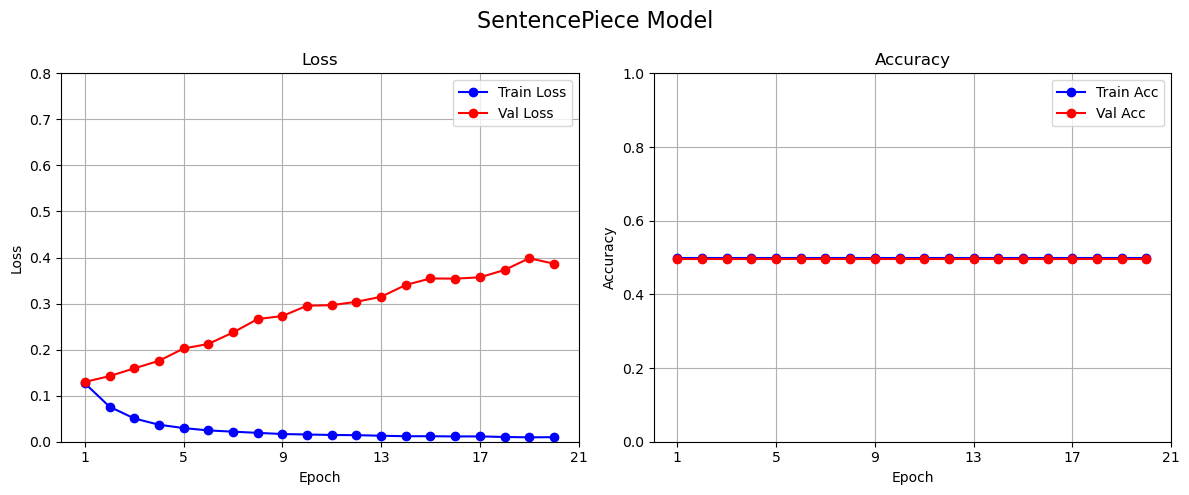

In [135]:
plot_training_history(
    lstm_train_losses,
    lstm_val_losses,
    lstm_train_accs,
    lstm_val_accs,
    title="SentencePiece Model"
)

### **학습된 모델로 sp_tokensize() 메소드 구현하기**

In [124]:
def sp_tokenize(s, corpus):

    tensor = []

    for sen in corpus:
        tensor.append(torch.tensor(s.EncodeAsIds(sen)))

    with open("./korean_spm.vocab", 'r') as f:
        vocab = f.readlines()

    word_index = {}
    index_word = {}

    for idx, line in enumerate(vocab):
        word = line.split("\t")[0]

        word_index.update({word:idx})
        index_word.update({idx:word})

    tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

    return tensor, word_index, index_word

In [122]:
train_data['document']

0                                       아 더빙.. 진짜 짜증나네요 목소리
1                         흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
2                                         너무재밓었다그래서보는것을추천한다
3                             교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
4         사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...
                                ...                        
149995                                  인간이 문제지.. 소는 뭔죄인가..
149996                                        평점이 너무 낮아서...
149997                      이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?
149998                          청춘 영화의 최고봉.방황과 우울했던 날들의 자화상
149999                             한국 영화 최초로 수간하는 내용이 담긴 영화
Name: document, Length: 146081, dtype: object

In [127]:
X_train2, _, _ = sp_tokenize(sp, train_data['document'])
X_test2, _, _ = sp_tokenize(sp, test_data['document'])

y_train = torch.tensor(train_data['label'].values, dtype=torch.float)
y_test  = torch.tensor(test_data['label'].values, dtype=torch.float)


train_dataset2 = TensorDataset(X_train2, y_train)
test_dataset2  = TensorDataset(X_test2, y_test)

# 4️⃣ train / val 분리
train_size = int(0.8 * len(train_dataset2))
val_size = len(train_dataset2) - train_size

train_dataset2, val_dataset2 = random_split(
    train_dataset2,
    [train_size, val_size]
)


train_loader2 = DataLoader(train_dataset2, batch_size=64, shuffle=True)
test_loader2  = DataLoader(test_dataset2, batch_size=64, shuffle=False)
val_loader2  = DataLoader(val_dataset2, batch_size=64, shuffle=False)

### **구현된 토크나이저를 적용하여 네이버 영화리뷰 감정 분석 모델을 재학습하기**

In [128]:
lstm_train_losses2, lstm_val_losses2, lstm_train_accs2, lstm_val_accs2 = train(lstm_model, EPOCH, loss_fn,torch.optim.RMSprop(lstm_model.parameters(), lr=0.001), train_loader2, val_loader2)

Using device: cuda
Epoch 1/20 - Train Loss: 0.0698, Train Acc: 0.4992 - Val Loss: 0.0716, Val Acc: 0.4946
Epoch 2/20 - Train Loss: 0.0319, Train Acc: 0.4992 - Val Loss: 0.0876, Val Acc: 0.4946
Epoch 3/20 - Train Loss: 0.0210, Train Acc: 0.4992 - Val Loss: 0.1064, Val Acc: 0.4946
Epoch 4/20 - Train Loss: 0.0167, Train Acc: 0.4992 - Val Loss: 0.1219, Val Acc: 0.4946
Epoch 5/20 - Train Loss: 0.0136, Train Acc: 0.4992 - Val Loss: 0.1393, Val Acc: 0.4946
Epoch 6/20 - Train Loss: 0.0125, Train Acc: 0.4992 - Val Loss: 0.1654, Val Acc: 0.4946
Epoch 7/20 - Train Loss: 0.0114, Train Acc: 0.4992 - Val Loss: 0.1557, Val Acc: 0.4946
Epoch 8/20 - Train Loss: 0.0101, Train Acc: 0.4992 - Val Loss: 0.1864, Val Acc: 0.4946
Epoch 9/20 - Train Loss: 0.0099, Train Acc: 0.4992 - Val Loss: 0.1853, Val Acc: 0.4946
Epoch 10/20 - Train Loss: 0.0099, Train Acc: 0.4992 - Val Loss: 0.1810, Val Acc: 0.4946
Epoch 11/20 - Train Loss: 0.0097, Train Acc: 0.4992 - Val Loss: 0.2022, Val Acc: 0.4946
Epoch 12/20 - Train Lo

In [133]:
lstm_test_loss2, lstm_test_acc2 = test(lstm_model, test_loader2)

Test Loss: 1.1531, Test Accuracy: 0.5039


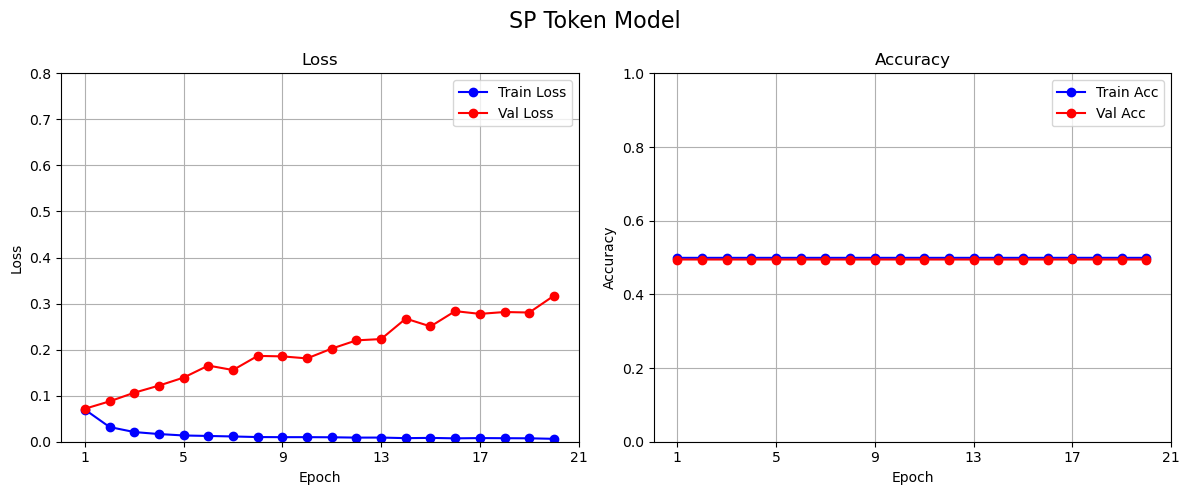

In [138]:
plot_training_history(
    lstm_train_losses2,
    lstm_val_losses2,
    lstm_train_accs2,
    lstm_val_accs2,
    title="SP Token Model"
)

### **KoNLPy 형태소 분석기를 사용한 모델과 성능 비교하기**

In [131]:

# 전체 train tensor
x_train_tensor3 = torch.tensor(x_train_padded, dtype=torch.long)
y_train_tensor3 = torch.tensor(y_train, dtype=torch.float)

# 전체 dataset
full_dataset3 = TensorDataset(x_train_tensor3, y_train_tensor3)

# 🔥 0.8 / 0.2 분리
train_size3 = int(0.8 * len(full_dataset3))
val_size3 = len(full_dataset3) - train_size3

train_dataset3, val_dataset3 = random_split(
    full_dataset3,
    [train_size3, val_size3],
)

# DataLoader
train_loader3 = DataLoader(train_dataset3, batch_size=128, shuffle=True)
val_loader3   = DataLoader(val_dataset3, batch_size=128, shuffle=False)


### test data ###
x_test_tensor3 = torch.tensor(x_test_padded, dtype=torch.long)
y_test_tensor3 = torch.tensor(y_test, dtype=torch.float)

test_dataset3 = TensorDataset(x_test_tensor3, y_test_tensor)
test_loader3  = DataLoader(test_dataset3, batch_size=128, shuffle=False)

/tmp/ipykernel_87/9614009.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tensor3 = torch.tensor(x_train_padded, dtype=torch.long)
/tmp/ipykernel_87/9614009.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor3 = torch.tensor(y_train, dtype=torch.float)
/tmp/ipykernel_87/9614009.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test_tensor3 = torch.tensor(x_test_padded, dtype=torch.long)
/tmp/ipykernel_87/9614009.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detac

In [142]:
lstm_train_losses3, lstm_val_losses3, lstm_train_accs3, lstm_val_accs3 = train(lstm_model, EPOCH, loss_fn,torch.optim.RMSprop(lstm_model.parameters(), lr=0.001), train_loader3, val_loader3)

Using device: cuda
Epoch 1/20 - Train Loss: 0.2849, Train Acc: 0.4981 - Val Loss: 0.3817, Val Acc: 0.4990
Epoch 2/20 - Train Loss: 0.2621, Train Acc: 0.4981 - Val Loss: 0.3884, Val Acc: 0.4990
Epoch 3/20 - Train Loss: 0.2493, Train Acc: 0.4981 - Val Loss: 0.3892, Val Acc: 0.4990
Epoch 4/20 - Train Loss: 0.2389, Train Acc: 0.4981 - Val Loss: 0.3911, Val Acc: 0.4990
Epoch 5/20 - Train Loss: 0.2296, Train Acc: 0.4981 - Val Loss: 0.4009, Val Acc: 0.4990
Epoch 6/20 - Train Loss: 0.2221, Train Acc: 0.4981 - Val Loss: 0.4006, Val Acc: 0.4990
Epoch 7/20 - Train Loss: 0.2148, Train Acc: 0.4981 - Val Loss: 0.4054, Val Acc: 0.4990
Epoch 8/20 - Train Loss: 0.2082, Train Acc: 0.4981 - Val Loss: 0.4113, Val Acc: 0.4990
Epoch 9/20 - Train Loss: 0.2021, Train Acc: 0.4981 - Val Loss: 0.4105, Val Acc: 0.4990
Epoch 10/20 - Train Loss: 0.1955, Train Acc: 0.4981 - Val Loss: 0.4159, Val Acc: 0.4990
Epoch 11/20 - Train Loss: 0.1911, Train Acc: 0.4981 - Val Loss: 0.4205, Val Acc: 0.4990
Epoch 12/20 - Train Lo

In [143]:
lstm_test_loss3, lstm_test_acc3 = test(lstm_model, test_loader3)

Test Loss: 0.4614, Test Accuracy: 0.5028


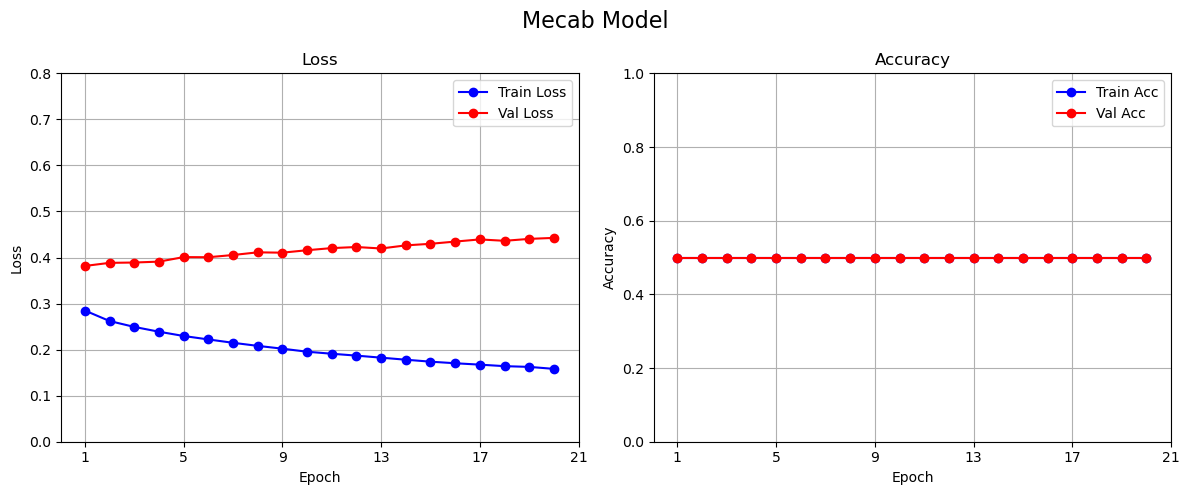

In [144]:
plot_training_history(
    lstm_train_losses3,
    lstm_val_losses3,
    lstm_train_accs3,
    lstm_val_accs3,
    title="Mecab Model"
)

### **SentencePiece 모델의 model_type, vocab_size 등을 변경해 가면서 성능 개선 여부 확인하기**

#### BPE(Byte Pair Encoding) 으로 변경

In [145]:
spm.SentencePieceTrainer.Train(
    input='nsmc.txt',
    model_prefix='spm_bpe',
    vocab_size=8000,
    model_type='bpe'
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc.txt
  input_format: 
  model_prefix: spm_bpe
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_p

In [146]:

# 1️⃣ 데이터 로드
x_train4, y_train4, x_test4, y_test4 = load_data_sp(train_data, test_data)

# 2️⃣ padding
x_train_padded4 = torch.nn.utils.rnn.pad_sequence(
    [torch.tensor(seq) for seq in x_train4], 
    batch_first=True,
    padding_value=0
)

x_test_padded4 = torch.nn.utils.rnn.pad_sequence(
    [torch.tensor(seq) for seq in x_test4],
    batch_first=True,
    padding_value=0
)

x_train_tensor4 = torch.tensor(x_train_padded4, dtype=torch.long)
y_train_tensor4 = torch.tensor(y_train4, dtype=torch.float)

x_test_tensor4 = torch.tensor(x_test_padded4, dtype=torch.long)
y_test_tensor4 = torch.tensor(y_test4, dtype=torch.float)


# 3️⃣ dataset 생성
full_train_dataset4 = TensorDataset(x_train_tensor4, y_train_tensor4)
test_dataset4 = TensorDataset(x_test_tensor4, y_test_tensor4)

# 4️⃣ train / val 분리
train_size = int(0.8 * len(full_train_dataset4))
val_size = len(full_train_dataset) - train_size

train_dataset4, val_dataset4 = random_split(
    full_train_dataset4,
    [train_size, val_size]
)

# 5️⃣ DataLoader 생성
train_loader4 = DataLoader(train_dataset4, batch_size=64, shuffle=True)
val_loader4   = DataLoader(val_dataset4, batch_size=64, shuffle=False)
test_loader4  = DataLoader(test_dataset4, batch_size=64, shuffle=False)

/tmp/ipykernel_87/2208557633.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tensor4 = torch.tensor(x_train_padded4, dtype=torch.long)
/tmp/ipykernel_87/2208557633.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_test_tensor4 = torch.tensor(x_test_padded4, dtype=torch.long)


In [147]:
lstm_train_losses4, lstm_val_losses4, lstm_train_accs4, lstm_val_accs4 = train(lstm_model, EPOCH, loss_fn,torch.optim.RMSprop(lstm_model.parameters(), lr=0.001), train_loader4, val_loader4)

Using device: cuda
Epoch 1/20 - Train Loss: 0.2195, Train Acc: 0.4978 - Val Loss: 0.2253, Val Acc: 0.5003
Epoch 2/20 - Train Loss: 0.2095, Train Acc: 0.4978 - Val Loss: 0.2346, Val Acc: 0.5003
Epoch 3/20 - Train Loss: 0.2049, Train Acc: 0.4978 - Val Loss: 0.2405, Val Acc: 0.5003
Epoch 4/20 - Train Loss: 0.2001, Train Acc: 0.4978 - Val Loss: 0.2480, Val Acc: 0.5003
Epoch 5/20 - Train Loss: 0.1948, Train Acc: 0.4978 - Val Loss: 0.2509, Val Acc: 0.5003
Epoch 6/20 - Train Loss: 0.1911, Train Acc: 0.4978 - Val Loss: 0.2556, Val Acc: 0.5003
Epoch 7/20 - Train Loss: 0.1873, Train Acc: 0.4978 - Val Loss: 0.2628, Val Acc: 0.5003
Epoch 8/20 - Train Loss: 0.1827, Train Acc: 0.4978 - Val Loss: 0.2675, Val Acc: 0.5003
Epoch 9/20 - Train Loss: 0.1793, Train Acc: 0.4978 - Val Loss: 0.2694, Val Acc: 0.5003
Epoch 10/20 - Train Loss: 0.1755, Train Acc: 0.4978 - Val Loss: 0.2749, Val Acc: 0.5003
Epoch 11/20 - Train Loss: 0.1714, Train Acc: 0.4978 - Val Loss: 0.2796, Val Acc: 0.5003
Epoch 12/20 - Train Lo

In [148]:
lstm_test_loss4, lstm_test_acc4 = test(lstm_model, test_loader4)

Test Loss: 0.4750, Test Accuracy: 0.5028


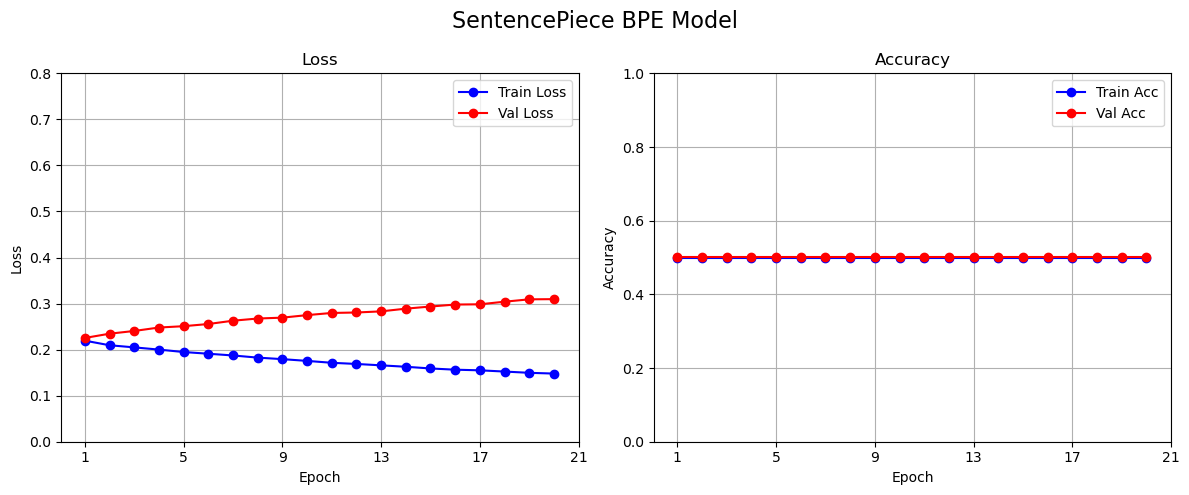

In [149]:
plot_training_history(
    lstm_train_losses4,
    lstm_val_losses4,
    lstm_train_accs4,
    lstm_val_accs4,
    title="SentencePiece BPE Model"
)

## 회고

- 토크나이저의 다름으로 어떤 결과의 차이를 내는지 알아보는 챕터였다
- 그러나 나의 모든 모델이 Loss 가 줄어들지 않는다. 슬프다. 그래도 NLP 전체 과정은 점점 익숙해지고 있다
- SentencePiece는 토크나이저로 텍스트를 subword인 토큰으로 쪼개서 이용하고 Word2Vec은 단어를 벡터로 바꾸는 임베딩을 통해서 모델을 학습한다
- SentencePiece는 OOV 문제를 해결하고 ,자동으로 vocab을 생성하는 장점이 있지만 토큰 분해가 부자연스러울 수 있다
- Word2Vec은 의미를 벡터로 표현하고 단어 유사도 계산이 가능하다는 장점이 있지만, OOV문제는 해결하지못하며 한국어에 약한 단점이 있다